# Quantitative Analysis — LVC (Leveraged CAC 40 ETF)

Comprehensive statistical analysis of LVC financial time series data.

**Contents**
1. Data Loading
2. Descriptive Statistics
3. Stationarity Testing (ADF + KPSS)
4. Normality Testing (Jarque-Bera, Shapiro-Wilk, Kolmogorov-Smirnov)
5. Autocorrelation & Volatility Analysis
6. Time Series Models (ARIMA / SARIMA / Exponential Smoothing)
7. Bootstrap Analysis
8. Hypothesis Testing
9. Summary


In [3]:
import os, warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from scipy import stats
from statsmodels.tsa.stattools import adfuller, kpss, pacf
from statsmodels.stats.stattools import jarque_bera
from statsmodels.stats.diagnostic import het_arch, acorr_ljungbox
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.holtwinters import ExponentialSmoothing
import statsmodels.api as sm

sns.set_style('whitegrid')
print("Libraries loaded.")


Libraries loaded.


## 1. Data Loading

In [5]:
# Load from the canonical CSV in Data/
data_dir = os.path.join(os.path.dirname(os.path.abspath("__file__")), "..", "Data")
lvc_path = os.path.join(data_dir, "lvc_ohlcv.csv")

df = pd.read_csv(lvc_path, parse_dates=["date"])
df.sort_values("date", inplace=True)
df.set_index("date", inplace=True)
df.columns = [c.title() for c in df.columns]  # Close, Open, High, Low, Volume

# Compute returns
df["Daily_Returns"] = df["Close"].pct_change()
df["Log_Returns"]   = np.log(df["Close"] / df["Close"].shift(1))

print(f"Loaded {len(df)} rows  ({df.index.min().date()} to {df.index.max().date()})")
df.head()


Loaded 4553 rows  (2008-05-23 to 2026-03-09)


,Open,High,Low,Close,Volume,Daily_Returns,Log_Returns
date,,,,,,,
2008-05-23,19.420000,19.420000,19.420000,19.420000,0,NaN,NaN
2008-05-26,18.680000,18.680000,18.680000,18.680000,0,-0.038105,-0.038850
2008-05-27,18.709999,18.709999,18.709999,18.709999,0,0.001606,0.001605
2008-05-28,18.469999,18.469999,18.469999,18.469999,0,-0.012827,-0.012910
2008-05-29,18.950001,18.950001,18.950001,18.950001,0,0.025988,0.025656


## 2. Descriptive Statistics


Daily Returns
  Statistic        Value
      Count  4552.000000
       Mean     0.000512
     Median     0.001369
    Std Dev     0.026376
        Min    -0.248820
        Max     0.219178
  25th pctl    -0.011185
  75th pctl     0.013308
   Skewness    -0.184136
   Kurtosis     8.468594
Jarque-Bera 13593.962153
 JB p-value     0.000000

Log Returns
  Statistic        Value
      Count  4552.000000
       Mean     0.000162
     Median     0.001369
    Std Dev     0.026523
        Min    -0.286111
        Max     0.198177
  25th pctl    -0.011248
  75th pctl     0.013220
   Skewness    -0.606836
   Kurtosis     9.302556
Jarque-Bera 16651.812180
 JB p-value     0.000000


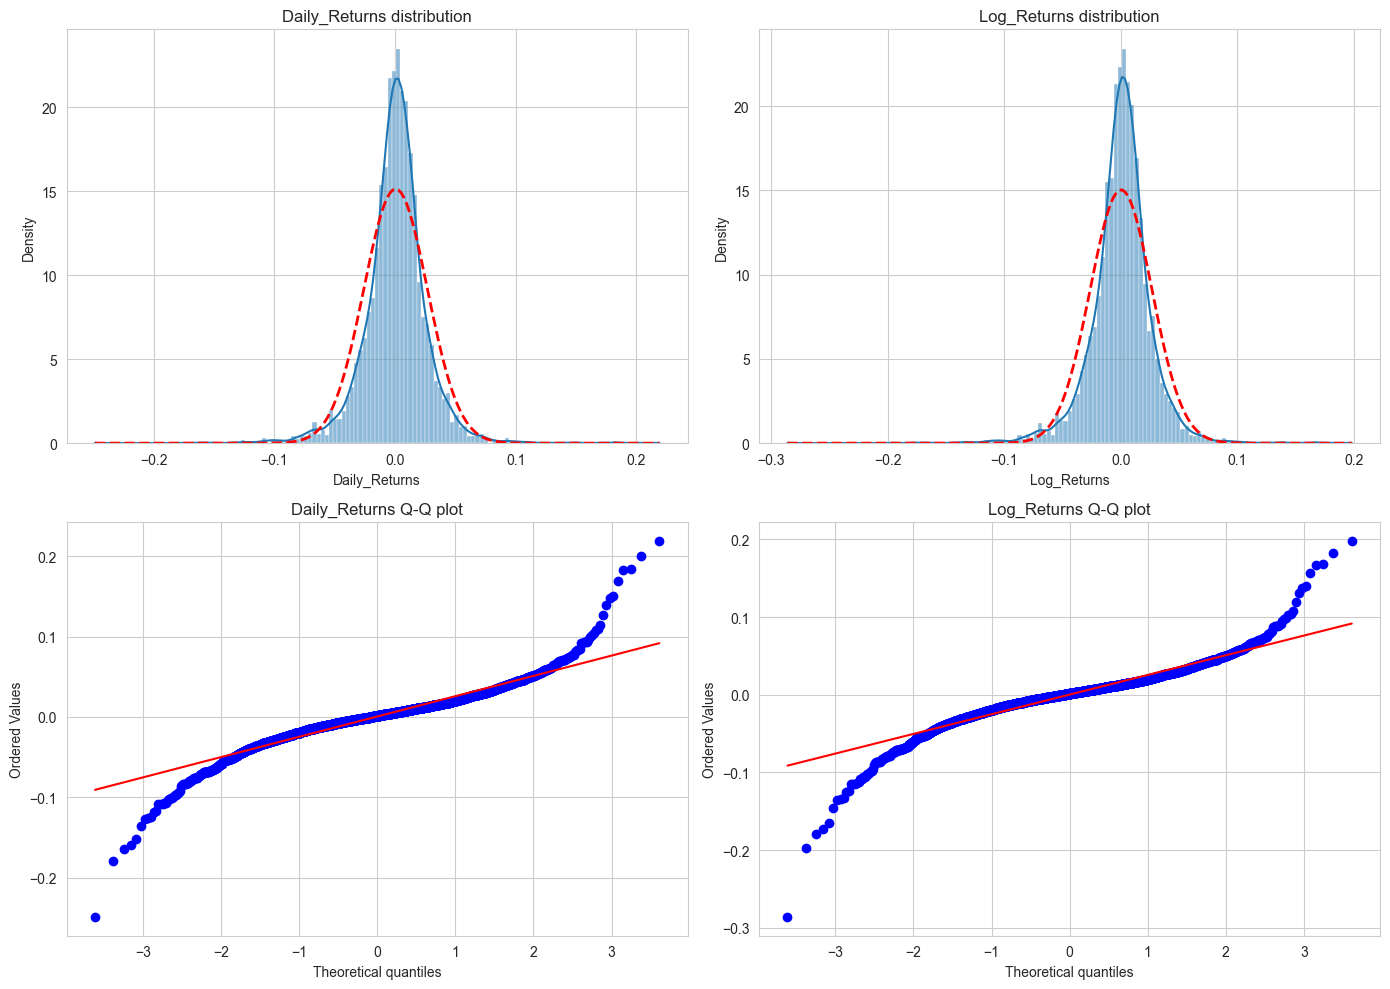

In [6]:
def descriptive_stats(returns, label):
    r = returns.dropna()
    jb_stat, jb_p, *_ = jarque_bera(r)
    tbl = pd.DataFrame({
        "Statistic": ["Count", "Mean", "Median", "Std Dev", "Min", "Max",
                       "25th pctl", "75th pctl", "Skewness", "Kurtosis",
                       "Jarque-Bera", "JB p-value"],
        "Value": [len(r), r.mean(), r.median(), r.std(), r.min(), r.max(),
                  r.quantile(0.25), r.quantile(0.75), r.skew(), r.kurt(),
                  jb_stat, jb_p]
    })
    tbl["Value"] = tbl["Value"].apply(lambda x: f"{x:.6f}" if isinstance(x, float) else x)
    print(f"\n{label}"); print(tbl.to_string(index=False))
    return tbl

descriptive_stats(df["Daily_Returns"], "Daily Returns")
descriptive_stats(df["Log_Returns"],   "Log Returns")

# Distribution + QQ plots
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
for i, col in enumerate(["Daily_Returns", "Log_Returns"]):
    s = df[col].dropna()
    # histogram
    ax = axes[0, i]
    sns.histplot(s, kde=True, stat="density", ax=ax)
    x = np.linspace(s.min(), s.max(), 200)
    ax.plot(x, stats.norm.pdf(x, s.mean(), s.std()), "r--", lw=2)
    ax.set_title(f"{col} distribution")
    # QQ
    ax = axes[1, i]
    stats.probplot(s, dist="norm", plot=ax)
    ax.set_title(f"{col} Q-Q plot")
plt.tight_layout(); plt.show()


## 3. Stationarity Testing

| ADF | KPSS | Interpretation |
|---|---|---|
| Reject H0 | Fail to reject H0 | Strong evidence for **stationarity** |
| Fail to reject H0 | Reject H0 | Strong evidence for **non-stationarity** |
| Reject H0 | Reject H0 | Contradictory — possible structural breaks |
| Fail to reject H0 | Fail to reject H0 | Insufficient evidence / fractionally integrated |


In [ ]:
def stationarity_decision(series, title, alpha=0.05):
    s = series.dropna()
    adf_stat, adf_p, *_ = adfuller(s)
    kpss_stat, kpss_p, *_ = kpss(s, regression="c", nlags="auto")
    adf_ok  = adf_p < alpha
    kpss_ok = kpss_p > alpha

    print(f"\n{'=' * 60}")
    print(f"  {title}")
    print(f"{'=' * 60}")
    print(f"  ADF  stat={adf_stat:.4f}  p={adf_p:.4f}  => {'Stationary' if adf_ok else 'Non-stationary'}")
    print(f"  KPSS stat={kpss_stat:.4f}  p={kpss_p:.4f}  => {'Stationary' if kpss_ok else 'Non-stationary'}")

    if adf_ok and kpss_ok:
        print("  >> STRONG EVIDENCE FOR STATIONARITY")
    elif not adf_ok and not kpss_ok:
        print("  >> STRONG EVIDENCE FOR NON-STATIONARITY")
    else:
        print("  >> MIXED — possible structural breaks or fractional integration")

    # Rolling stats plot
    roll_mean = s.rolling(20).mean()
    roll_std  = s.rolling(20).std()
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 6), sharex=True)
    ax1.plot(s.index, s, alpha=0.6, label="Series")
    ax1.plot(roll_mean.index, roll_mean, "r", label="Rolling mean (20)")
    ax1.set_title(title); ax1.legend(); ax1.grid(True, alpha=0.3)
    ax2.plot(roll_std.index, roll_std, "k", label="Rolling std (20)")
    ax2.legend(); ax2.grid(True, alpha=0.3)
    plt.tight_layout(); plt.show()

stationarity_decision(df["Close"],       "Price Levels")
stationarity_decision(df["Log_Returns"], "Log Returns")


In [7]:
# Multi-frequency stationarity comparison
def multi_freq_stationarity(price_series):
    daily   = price_series; weekly  = price_series.resample("W").last()
    monthly = price_series.resample("ME").last()
    rows = []
    for label, prices in [("Daily", daily), ("Weekly", weekly), ("Monthly", monthly)]:
        ret = np.log(prices / prices.shift(1)).dropna()
        adf_s, adf_p, *_ = adfuller(prices.dropna())
        adf_rs, adf_rp, *_ = adfuller(ret)
        rows.append({"Freq": label,
                      "Price ADF p": f"{adf_p:.4f}",
                      "Price Stationary?": "Yes" if adf_p < 0.05 else "No",
                      "Return ADF p": f"{adf_rp:.4f}",
                      "Return Stationary?": "Yes" if adf_rp < 0.05 else "No"})
    print(pd.DataFrame(rows).to_string(index=False))

multi_freq_stationarity(df["Close"])


   Freq Price ADF p Price Stationary? Return ADF p Return Stationary?
  Daily      0.9045                No       0.0000                Yes
 Weekly      0.9500                No       0.0000                Yes
Monthly      0.9081                No       0.0000                Yes


## 4. Normality Testing


  Normality — Daily Returns  (n=4552)
  Skewness : -0.1841  (Approx symmetric)
  Kurtosis : 8.4686  (Extremely leptokurtic (very heavy tails))
  Jarque-Bera  stat=13593.9622  p=0.000000  Non-normal
  Kolm-Smirnov stat=0.0803  p=0.000000  Non-normal
  Shapiro-Wilk stat=0.9177  p=0.000000  Non-normal


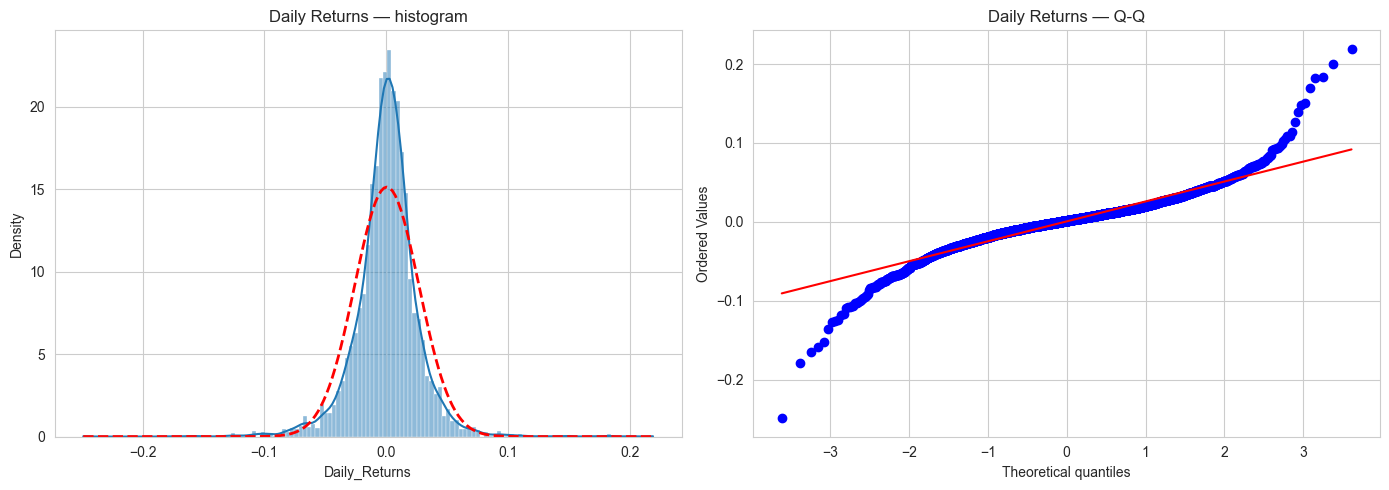


  Normality — Log Returns  (n=4552)
  Skewness : -0.6068  (Moderately negatively skewed)
  Kurtosis : 9.3026  (Extremely leptokurtic (very heavy tails))
  Jarque-Bera  stat=16651.8122  p=0.000000  Non-normal
  Kolm-Smirnov stat=0.0850  p=0.000000  Non-normal
  Shapiro-Wilk stat=0.9127  p=0.000000  Non-normal


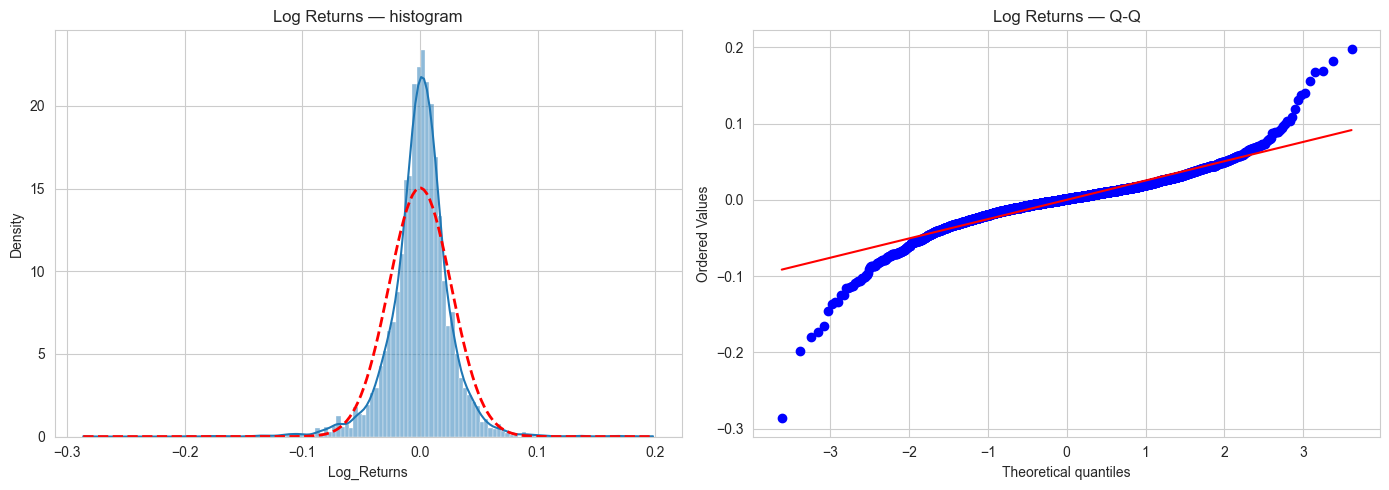


  Normality — Weekly Returns  (n=929)
  Skewness : -0.6405  (Moderately negatively skewed)
  Kurtosis : 4.0203  (Extremely leptokurtic (very heavy tails))
  Jarque-Bera  stat=680.2314  p=0.000000  Non-normal
  Kolm-Smirnov stat=0.0558  p=0.005952  Non-normal
  Shapiro-Wilk stat=0.9610  p=0.000000  Non-normal


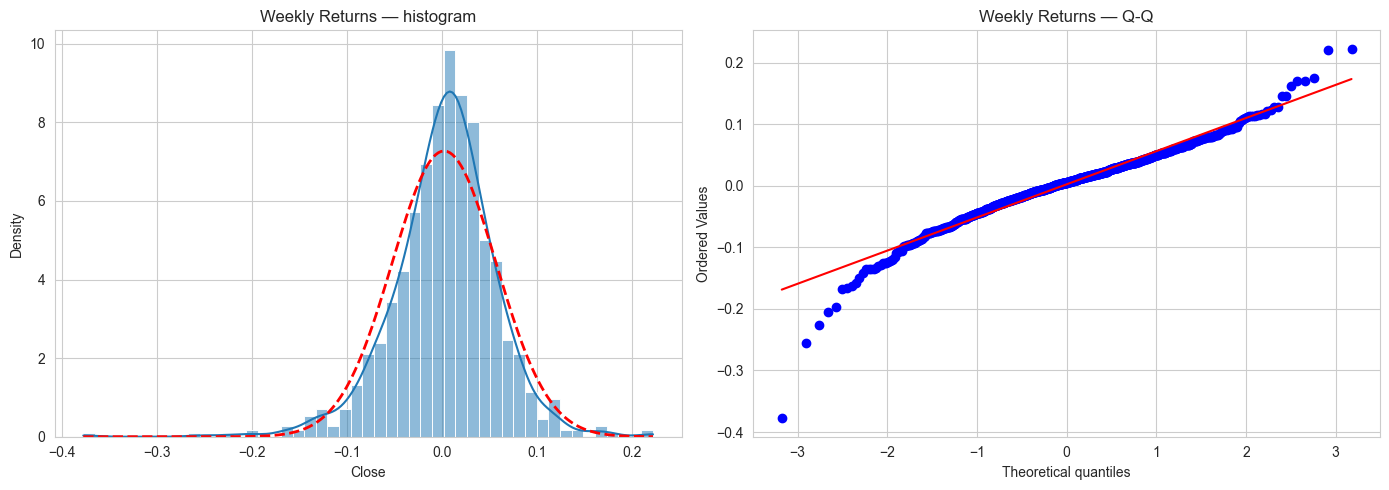


  Normality — Monthly Returns  (n=214)
  Skewness : -0.0844  (Approx symmetric)
  Kurtosis : 1.7355  (Highly leptokurtic (heavy tails))
  Jarque-Bera  stat=25.0373  p=0.000004  Non-normal
  Kolm-Smirnov stat=0.0415  p=0.840368  Normal
  Shapiro-Wilk stat=0.9818  p=0.007345  Non-normal


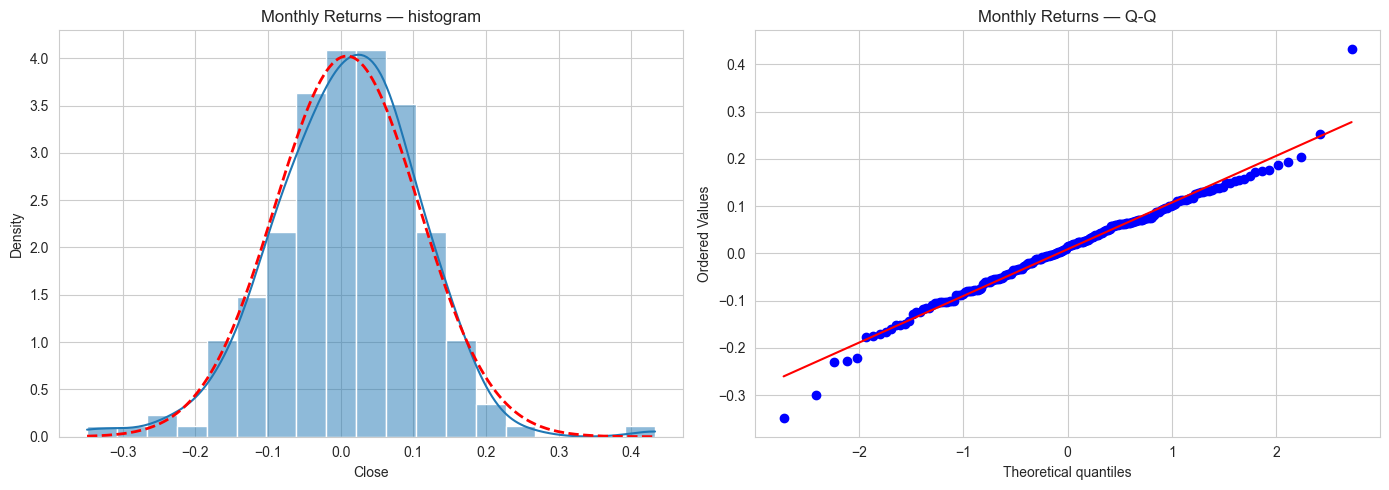

In [8]:
def interpret_skew(s):
    if abs(s) < 0.5: return "Approx symmetric"
    d = "negative" if s < 0 else "positive"
    m = "Highly" if abs(s) > 1 else "Moderately"
    return f"{m} {d}ly skewed"

def interpret_kurt(k):
    if abs(k) < 0.5: return "Mesokurtic (normal-like)"
    if k > 3: return "Extremely leptokurtic (very heavy tails)"
    if k > 1: return "Highly leptokurtic (heavy tails)"
    if k > 0: return "Moderately leptokurtic"
    return "Platykurtic (thin tails)"

def normality_tests(series, title):
    s = series.dropna()
    jb_stat, jb_p = stats.jarque_bera(s)
    ks_stat, ks_p = stats.kstest(s, "norm", args=(s.mean(), s.std()))
    sw_stat, sw_p = (None, None)
    if len(s) <= 5000:
        sw_stat, sw_p = stats.shapiro(s)

    print(f"\n{'=' * 60}")
    print(f"  Normality — {title}  (n={len(s)})")
    print(f"{'=' * 60}")
    print(f"  Skewness : {s.skew():.4f}  ({interpret_skew(s.skew())})")
    print(f"  Kurtosis : {s.kurt():.4f}  ({interpret_kurt(s.kurt())})")
    print(f"  Jarque-Bera  stat={jb_stat:.4f}  p={jb_p:.6f}  {'Normal' if jb_p > 0.05 else 'Non-normal'}")
    print(f"  Kolm-Smirnov stat={ks_stat:.4f}  p={ks_p:.6f}  {'Normal' if ks_p > 0.05 else 'Non-normal'}")
    if sw_stat is not None:
        print(f"  Shapiro-Wilk stat={sw_stat:.4f}  p={sw_p:.6f}  {'Normal' if sw_p > 0.05 else 'Non-normal'}")

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
    sns.histplot(s, kde=True, stat="density", ax=ax1)
    x = np.linspace(s.min(), s.max(), 200)
    ax1.plot(x, stats.norm.pdf(x, s.mean(), s.std()), "r--", lw=2)
    ax1.set_title(f"{title} — histogram")
    stats.probplot(s, dist="norm", plot=ax2)
    ax2.set_title(f"{title} — Q-Q")
    plt.tight_layout(); plt.show()

normality_tests(df["Daily_Returns"], "Daily Returns")
normality_tests(df["Log_Returns"],   "Log Returns")

# Weekly / Monthly aggregation
weekly_ret  = df["Close"].resample("W").last().pct_change().dropna()
monthly_ret = df["Close"].resample("ME").last().pct_change().dropna()
normality_tests(weekly_ret,  "Weekly Returns")
normality_tests(monthly_ret, "Monthly Returns")


## 5. Autocorrelation & Volatility Analysis

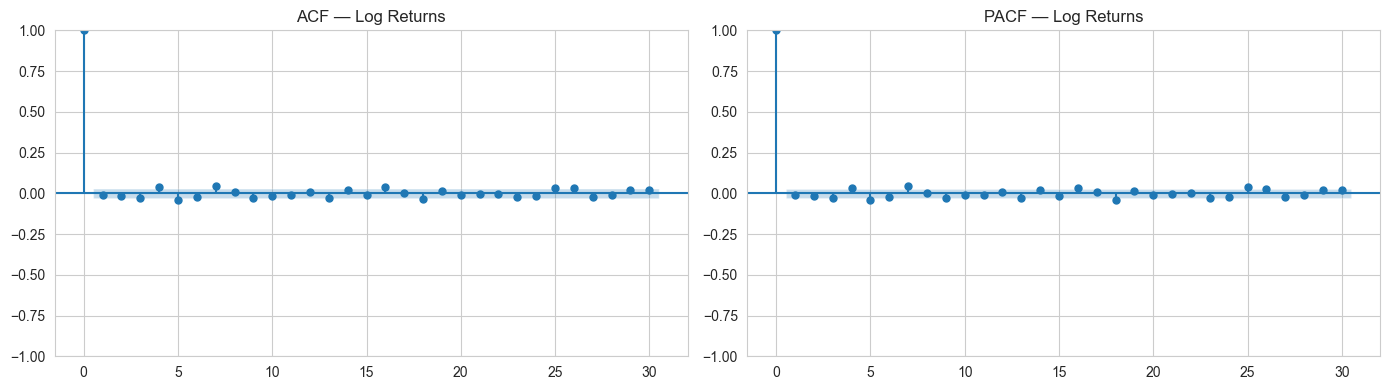

Ljung-Box test (H0: no autocorrelation):
      lb_stat  lb_pvalue
10  34.374664   0.000160
20  54.964806   0.000042
30  75.436429   0.000009

ARCH test  stat=821.2262  p=0.000000  => ARCH effect


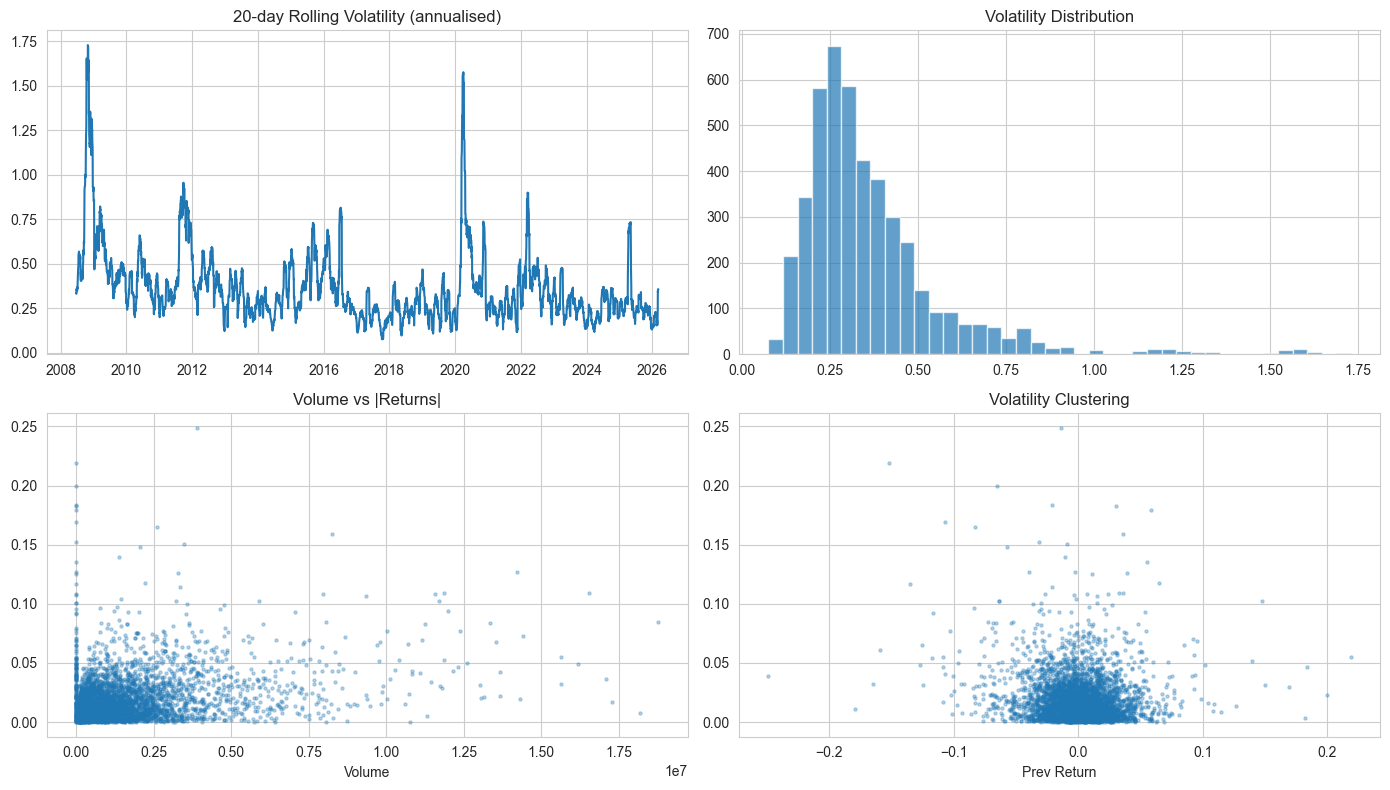

In [9]:
log_ret = df["Log_Returns"].dropna()

# ACF / PACF
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4))
sm.graphics.tsa.plot_acf(log_ret, lags=30, ax=ax1, title="ACF — Log Returns")
sm.graphics.tsa.plot_pacf(log_ret, lags=30, ax=ax2, title="PACF — Log Returns")
plt.tight_layout(); plt.show()

# Ljung-Box test
lb = acorr_ljungbox(log_ret, lags=[10, 20, 30], return_df=True)
print("Ljung-Box test (H0: no autocorrelation):"); print(lb)

# ARCH effect
arch_stat, arch_p, *_ = het_arch(log_ret)
print(f"\nARCH test  stat={arch_stat:.4f}  p={arch_p:.6f}  => {'ARCH effect' if arch_p < 0.05 else 'No ARCH effect'}")

# Volatility analysis
fig, axes = plt.subplots(2, 2, figsize=(14, 8))
vol20 = df["Daily_Returns"].rolling(20).std() * np.sqrt(252)
axes[0,0].plot(vol20.index, vol20); axes[0,0].set_title("20-day Rolling Volatility (annualised)")
axes[0,1].hist(vol20.dropna(), bins=40, alpha=0.7); axes[0,1].set_title("Volatility Distribution")
axes[1,0].scatter(df["Volume"], df["Daily_Returns"].abs(), alpha=0.3, s=5)
axes[1,0].set_title("Volume vs |Returns|"); axes[1,0].set_xlabel("Volume")
axes[1,1].scatter(df["Daily_Returns"].shift(1), df["Daily_Returns"].abs(), alpha=0.3, s=5)
axes[1,1].set_title("Volatility Clustering"); axes[1,1].set_xlabel("Prev Return")
plt.tight_layout(); plt.show()


## 6. Time Series Models (ARIMA / SARIMA / Exponential Smoothing)

ARIMA(1,1,1)
  AIC=5536.8  BIC=5556.1
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.0007      6.139     -0.000      1.000     -12.033      12.031
ma.L1         -0.0007      6.139     -0.000      1.000     -12.032      12.031
sigma2         0.1973      0.002    101.378      0.000       0.194       0.201

SARIMA(1,1,1)(1,1,0,5)
  AIC=7350.2  BIC=7375.9
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.0019      2.553      0.001      0.999      -5.002       5.006
ma.L1          0.0017      2.554      0.001      0.999      -5.005       5.008
ar.S.L5       -0.4926      0.008    -64.249      0.000      -0.508      -0.478
sigma2         0.2942      0.003     89.457      0.000       0.288       0.301

Exponential Smoothing (additive trend, damp

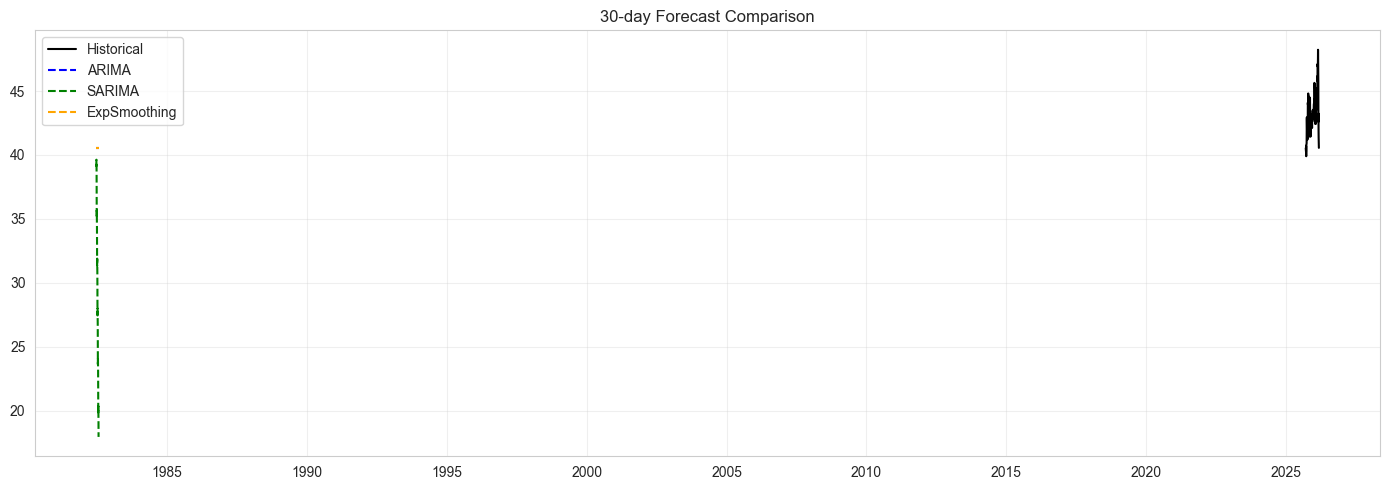

In [10]:
close = df["Close"].dropna()

# --- ARIMA ---
try:
    arima = ARIMA(close, order=(1, 1, 1)).fit()
    print("ARIMA(1,1,1)")
    print(f"  AIC={arima.aic:.1f}  BIC={arima.bic:.1f}")
    print(arima.summary().tables[1])
except Exception as e:
    print(f"ARIMA error: {e}"); arima = None

# --- SARIMA ---
try:
    sarima = SARIMAX(close, order=(1,1,1), seasonal_order=(1,1,0,5)).fit(disp=False)
    print(f"\nSARIMA(1,1,1)(1,1,0,5)")
    print(f"  AIC={sarima.aic:.1f}  BIC={sarima.bic:.1f}")
    print(sarima.summary().tables[1])
except Exception as e:
    print(f"SARIMA error: {e}"); sarima = None

# --- Exponential Smoothing ---
try:
    es = ExponentialSmoothing(close, trend="add", seasonal=None, damped_trend=True).fit()
    print(f"\nExponential Smoothing (additive trend, damped)")
    print(f"  AIC={es.aic:.1f}  BIC={es.bic:.1f}")
except Exception as e:
    print(f"ExpSmoothing error: {e}"); es = None

# Forecast comparison (30 days)
fcast_days = 30
fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(close.index[-120:], close.iloc[-120:], label="Historical", color="black")
for model, name, clr in [(arima, "ARIMA", "blue"),
                          (sarima, "SARIMA", "green"),
                          (es, "ExpSmoothing", "orange")]:
    if model is not None:
        fc = model.forecast(fcast_days)
        ax.plot(fc.index, fc.values, "--", color=clr, label=name)
ax.set_title(f"{fcast_days}-day Forecast Comparison")
ax.legend(); ax.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()


## 7. Bootstrap Analysis


Bootstrap (2000 resamples, 95% CI)
Statistic  Original Boot Mean Lower 95% Upper 95%
     Mean  0.000162  0.000170 -0.000595  0.000938
   Median  0.001369  0.001368  0.000722  0.001990
  Std Dev  0.026523  0.026514  0.025351  0.027842
 Skewness -0.606636 -0.597031 -1.263580 -0.011458
 Kurtosis  9.291023  9.153921  5.422630 14.103324
  VaR 95% -0.040957 -0.041019 -0.044045 -0.038641


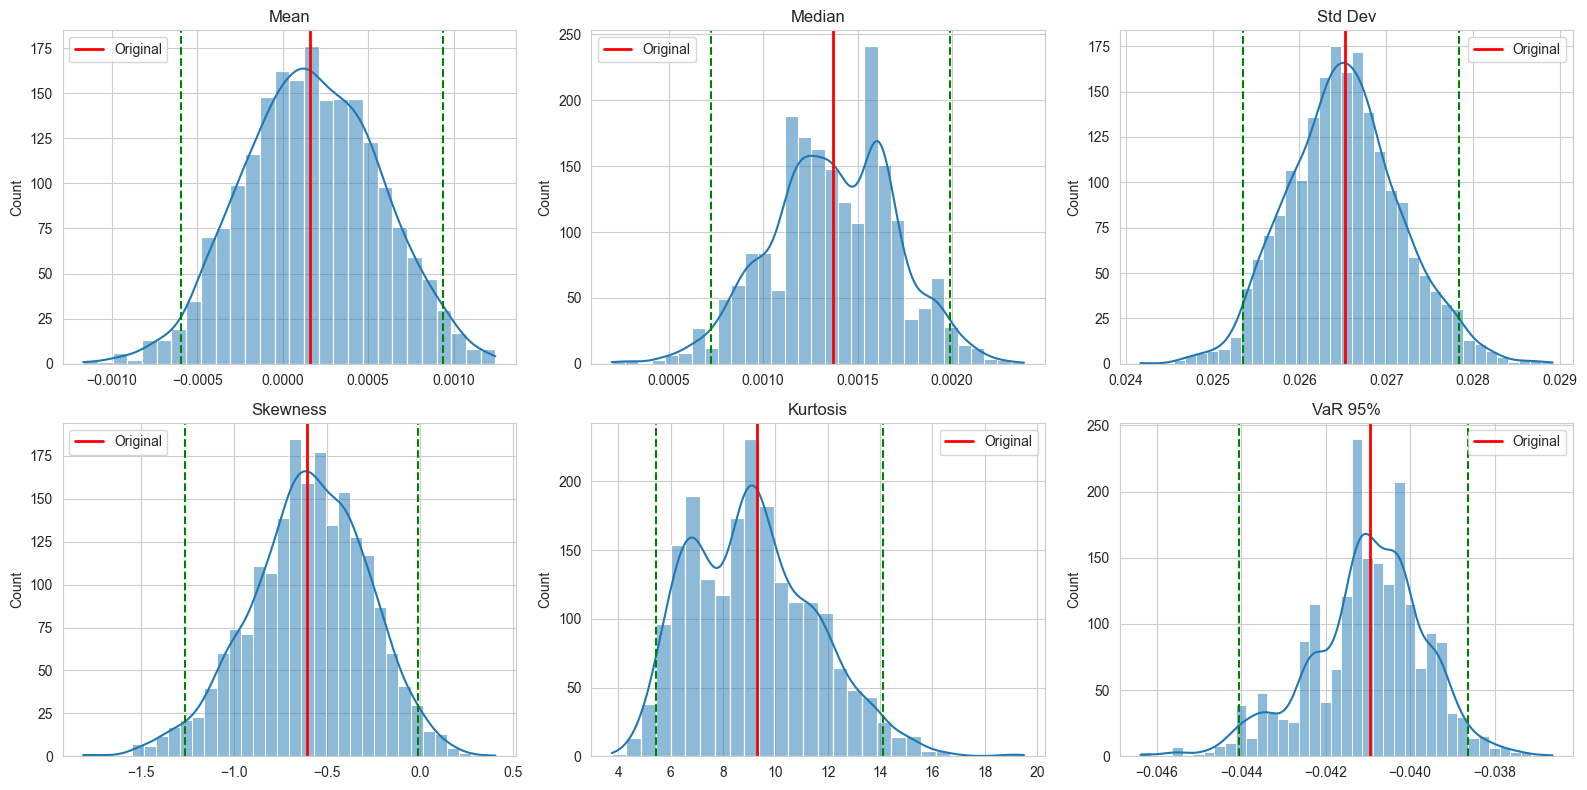


Parametric CI for mean: [-0.000609, 0.000932]
Bootstrap  CI for mean: [-0.000595, 0.000938]


In [11]:
def bootstrap_analysis(returns, n_boot=2000, ci=0.95):
    r = returns.dropna().values
    n = len(r)
    alpha = (1 - ci) / 2
    lo, hi = alpha * 100, (1 - alpha) * 100

    boot = np.random.choice(r, size=(n_boot, n), replace=True)
    b_mean   = boot.mean(axis=1)
    b_median = np.median(boot, axis=1)
    b_std    = boot.std(axis=1, ddof=1)
    b_skew   = stats.skew(boot, axis=1)
    b_kurt   = stats.kurtosis(boot, axis=1)
    b_var95  = np.percentile(boot, 5, axis=1)

    labels = ["Mean", "Median", "Std Dev", "Skewness", "Kurtosis", "VaR 95%"]
    originals = [r.mean(), np.median(r), r.std(ddof=1),
                 stats.skew(r), stats.kurtosis(r), np.percentile(r, 5)]
    boots = [b_mean, b_median, b_std, b_skew, b_kurt, b_var95]

    rows = []
    for lbl, orig, b in zip(labels, originals, boots):
        rows.append({"Statistic": lbl,
                      "Original": f"{orig:.6f}",
                      "Boot Mean": f"{b.mean():.6f}",
                      f"Lower {ci*100:.0f}%": f"{np.percentile(b, lo):.6f}",
                      f"Upper {ci*100:.0f}%": f"{np.percentile(b, hi):.6f}"})
    print(f"\nBootstrap ({n_boot} resamples, {ci*100:.0f}% CI)")
    print(pd.DataFrame(rows).to_string(index=False))

    fig, axes = plt.subplots(2, 3, figsize=(16, 8))
    for ax, lbl, orig, b in zip(axes.flat, labels, originals, boots):
        sns.histplot(b, kde=True, ax=ax)
        ax.axvline(orig, color="red", lw=2, label="Original")
        ax.axvline(np.percentile(b, lo), color="green", ls="--")
        ax.axvline(np.percentile(b, hi), color="green", ls="--")
        ax.set_title(lbl); ax.legend()
    plt.tight_layout(); plt.show()

    # Parametric vs bootstrap CI for mean
    se = r.std(ddof=1) / np.sqrt(n)
    t_crit = stats.t.ppf(1 - alpha, df=n-1)
    p_lo, p_hi = r.mean() - t_crit*se, r.mean() + t_crit*se
    print(f"\nParametric CI for mean: [{p_lo:.6f}, {p_hi:.6f}]")
    print(f"Bootstrap  CI for mean: [{np.percentile(b_mean, lo):.6f}, {np.percentile(b_mean, hi):.6f}]")

bootstrap_analysis(df["Log_Returns"])


## 8. Hypothesis Testing

One-Sample t-test: H0: mean return = 0  vs  H1: mean != 0
  n=4552  mean=0.000162  std=0.026523  SE=0.000393
  t-stat=0.4115  p-value=0.6807
  95% CI: [-0.000609, 0.000932]
  => Fail to reject H0


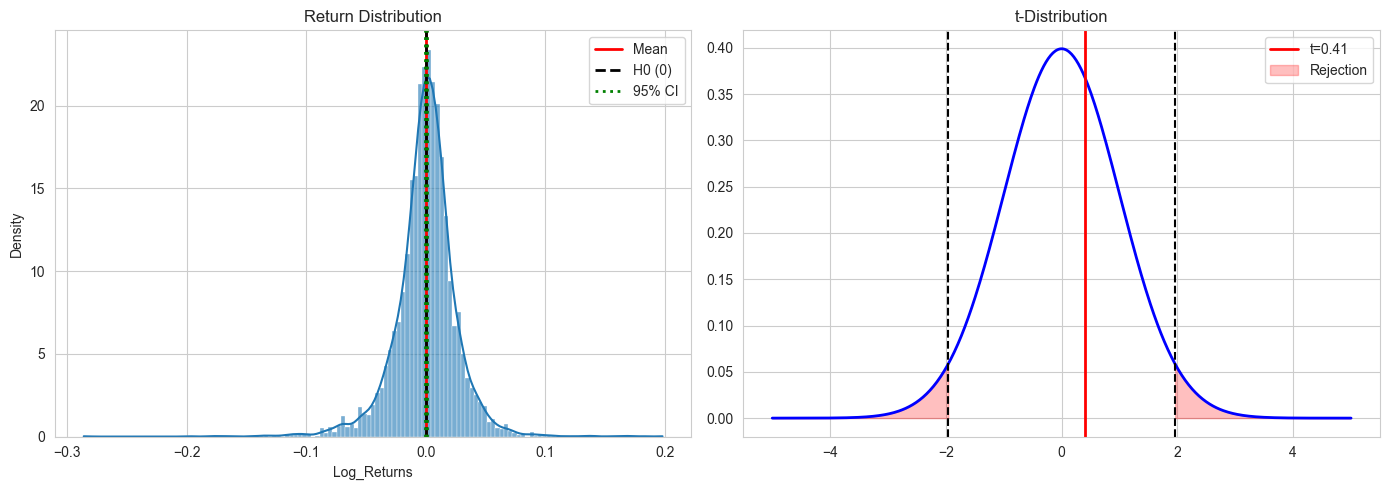

In [12]:
def hypothesis_test(returns, alpha=0.05):
    r = returns.dropna()
    n = len(r)
    t_stat, p_val = stats.ttest_1samp(r, 0)
    se = r.std() / np.sqrt(n)
    t_crit = stats.t.ppf(1 - alpha/2, df=n-1)
    ci_lo, ci_hi = r.mean() - t_crit*se, r.mean() + t_crit*se

    print("One-Sample t-test: H0: mean return = 0  vs  H1: mean != 0")
    print(f"  n={n}  mean={r.mean():.6f}  std={r.std():.6f}  SE={se:.6f}")
    print(f"  t-stat={t_stat:.4f}  p-value={p_val:.4f}")
    print(f"  {(1-alpha)*100:.0f}% CI: [{ci_lo:.6f}, {ci_hi:.6f}]")
    print(f"  => {'Reject H0' if p_val < alpha else 'Fail to reject H0'}")

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
    # Returns distribution
    sns.histplot(r, kde=True, stat="density", ax=ax1, alpha=0.6)
    ax1.axvline(r.mean(), color="red", lw=2, label="Mean")
    ax1.axvline(0, color="black", ls="--", lw=2, label="H0 (0)")
    ax1.axvline(ci_lo, color="green", ls=":", lw=2, label=f"{(1-alpha)*100:.0f}% CI")
    ax1.axvline(ci_hi, color="green", ls=":", lw=2)
    ax1.set_title("Return Distribution"); ax1.legend()

    # t-distribution with rejection regions
    x = np.linspace(-5, 5, 500)
    ax2.plot(x, stats.t.pdf(x, df=n-1), "b-", lw=2)
    ax2.axvline(t_stat, color="red", lw=2, label=f"t={t_stat:.2f}")
    ax2.axvline(t_crit, color="black", ls="--", lw=1.5)
    ax2.axvline(-t_crit, color="black", ls="--", lw=1.5)
    rej_l = np.linspace(-5, -t_crit, 100)
    rej_r = np.linspace(t_crit, 5, 100)
    ax2.fill_between(rej_l, stats.t.pdf(rej_l, df=n-1), color="red", alpha=0.25, label="Rejection")
    ax2.fill_between(rej_r, stats.t.pdf(rej_r, df=n-1), color="red", alpha=0.25)
    ax2.set_title("t-Distribution"); ax2.legend()
    plt.tight_layout(); plt.show()

hypothesis_test(df["Log_Returns"])


## Summary

**Key Findings**
- **Stationarity**: Price levels are non-stationary; log returns are stationary (ADF + KPSS agree).
- **Normality**: Returns are NOT normally distributed — negative skewness and excess kurtosis (fat tails).
- **Volatility**: Clear clustering visible; ARCH effect is present.
- **Autocorrelation**: Minimal serial correlation in raw returns.
- **Bootstrap**: Non-parametric CIs confirm non-normality; differ from parametric CIs.

**Implications for Modelling**
- Stationary returns can be modelled with ARIMA-class or ML models.
- Normal-distribution assumptions should be avoided — use robust statistics or bootstrap.
- Volatility clustering suggests GARCH-type models for risk management.
- Fat-tail risk is significant for this leveraged ETF.
